<a href="https://colab.research.google.com/github/VitorMansk/VitorMansk-Desafio-Construindo-um-modelo-de-Regress-o-para-marketing/blob/main/RID1234_Desafio03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Analise Descritiva


In [71]:
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
from xgboost import XGBRegressor
import numpy as np
import matplotlib.pyplot as plt

In [7]:
invest_mark = pd.read_csv('/content/MKT.csv', sep =",")

In [8]:
invest_mark.head()

,youtube,facebook,newspaper,sales
0,84.72,19.20,48.96,12.60
1,351.48,33.96,51.84,25.68
2,135.48,20.88,46.32,14.28
3,116.64,1.80,36.00,11.52
4,318.72,24.00,0.36,20.88


In [16]:
invest_mark.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   youtube    171 non-null    float64
 1   facebook   171 non-null    float64
 2   newspaper  171 non-null    float64
 3   sales      171 non-null    float64
dtypes: float64(4)
memory usage: 5.5 KB


In [9]:
invest_mark.describe()

,youtube,facebook,newspaper,sales
count,171.000000,171.000000,171.000000,171.000000
mean,178.021053,27.671579,35.240000,16.922807
std,102.449597,17.913532,24.902918,6.314608
min,0.840000,0.000000,0.360000,1.920000
25%,91.080000,11.700000,13.740000,12.540000
50%,179.760000,26.760000,31.080000,15.480000
75%,262.980000,43.680000,50.880000,20.820000
max,355.680000,59.520000,121.080000,32.400000


#Analise Exploratoria

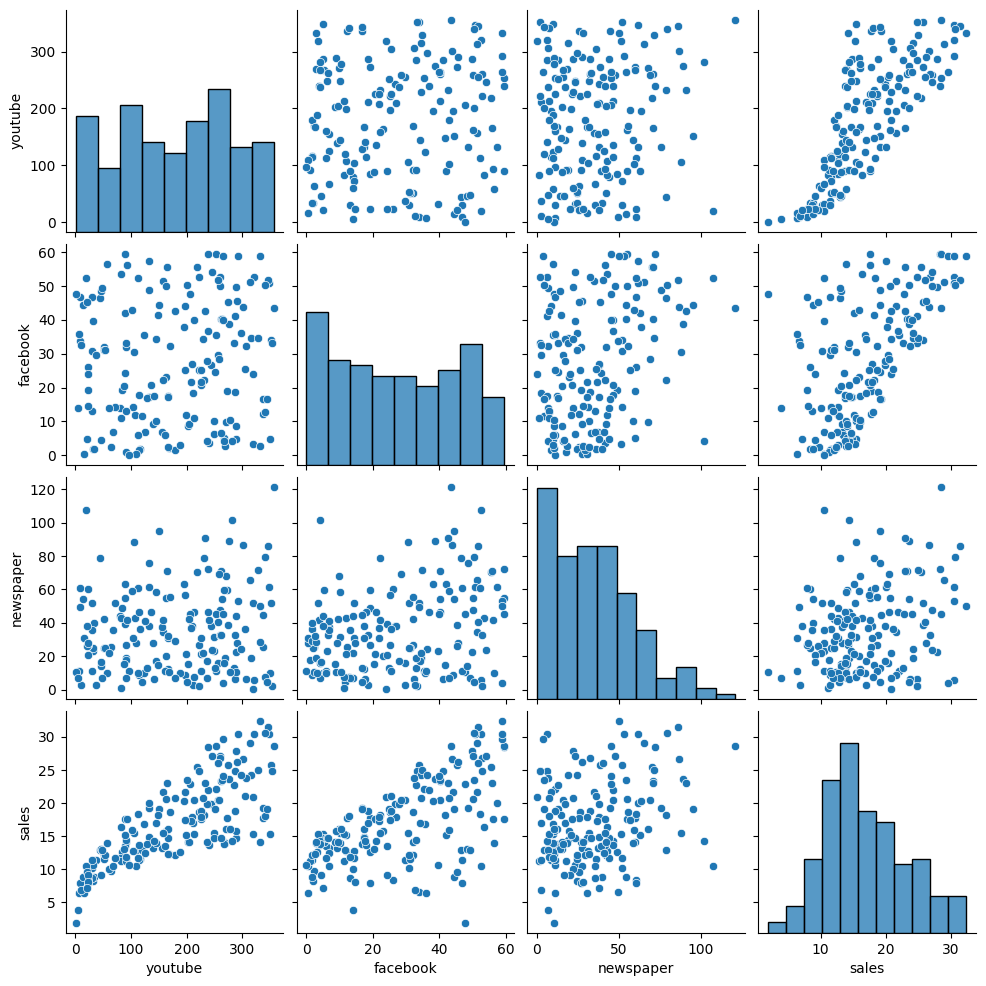

In [91]:
sns.pairplot(invest_mark)

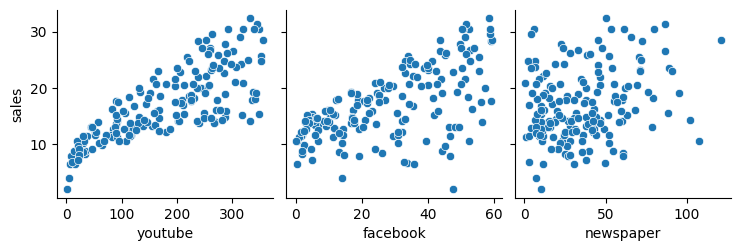

In [19]:
sns.pairplot(invest_mark, x_vars=['youtube', 'facebook', 'newspaper'], y_vars =['sales'])

In [20]:
invest_mark.corr()

,youtube,facebook,newspaper,sales
youtube,1.000000,0.086538,0.110759,0.782030
facebook,0.086538,1.000000,0.293425,0.602918
newspaper,0.110759,0.293425,1.000000,0.254987
sales,0.782030,0.602918,0.254987,1.000000


<Axes: >

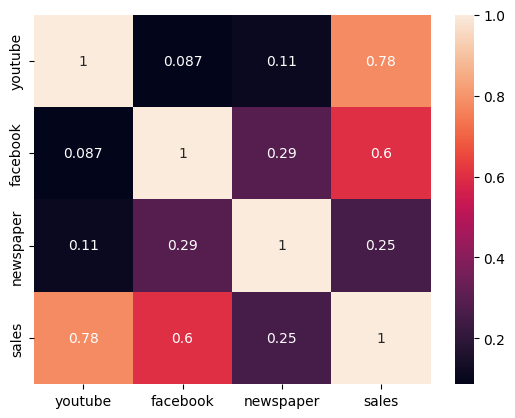

In [23]:
sns.heatmap(invest_mark.corr(), annot=True)

<Axes: xlabel='sales', ylabel='Count'>

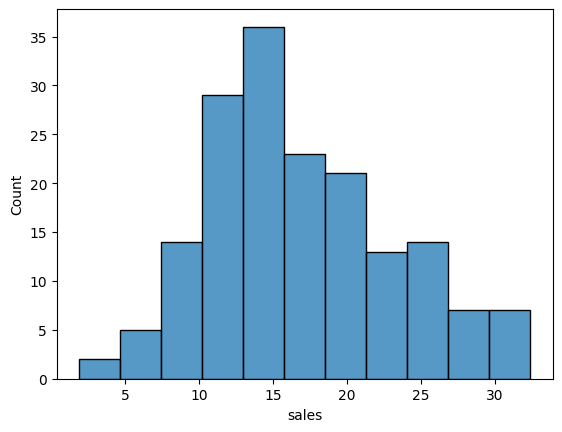

In [24]:
sns.histplot(invest_mark['sales'])

In [25]:
invest_mark.columns

Index(['youtube', 'facebook', 'newspaper', 'sales'], dtype='object')

In [34]:
X = invest_mark[['youtube', 'facebook', 'newspaper']]
y = invest_mark['sales']

#Modelagem

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, test_size = 0.3, random_state = 42)

In [87]:
redLinear = LinearRegression().fit(X_train,y_train)

In [88]:
yPredLilear = redLinear.predict(X_test)

In [89]:
MSELinear = mean_squared_error(y_test, yPredLilear)

In [90]:
print('MSE:', MSELinear)
print("RMSE:", np.sqrt(MSELinear))

MSE: 4.699445585122349
RMSE: 2.167820468840155


In [83]:
regSVR = SVR().fit(X_train, y_train)

In [84]:
ySVR = regSVR.predict(X_test)

In [85]:
MSESVR = mean_squared_error(y_test, yPredSVR)

In [86]:
print('MSE:', MSESVR)
print("RMSE:", np.sqrt(MSESVR))

MSE: 9.304486700664437
RMSE: 3.0503256712463402


In [59]:
regXGB = XGBRegressor().fit(X_train, y_train)

In [60]:
yXGB = regXGB.predict(X_test)

In [61]:
MSEXGB = mean_squared_error(y_test, yXGB)

In [62]:
print('MSE:', MSEXGB)
print("RMSE:", np.sqrt(MSEXGB))

MSE: 1.6327100952934968
RMSE: 1.2777754479146548


#Calculando Predição

In [66]:
lm = LinearRegression()

In [67]:
lm.fit(X_train,y_train)

LinearRegression()

Text(0, 0.5, 'Vendas de Marketing')

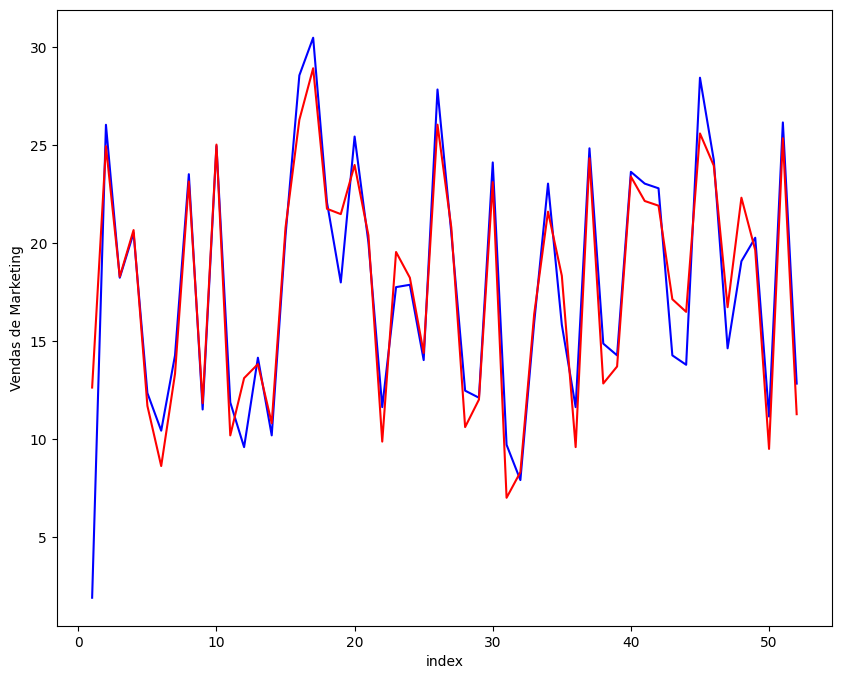

In [82]:
c = [i for i in range(1, len(y_test) + 1, 1)]
fig = plt.figure(figsize=(10,8))
plt.plot(c, y_test, color="blue", label='Actual Values')
plt.plot(c, y_pred, color = "red", label='Predicted Values')
plt.xlabel("index")
plt.ylabel("Vendas de Marketing")